In [12]:
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.legend_handler import HandlerLine2D
from matplotlib.backends.backend_pdf import PdfPages

import numpy as np

import lmfit as lm
from lmfit import Model, Parameters, Parameter, report_fit, minimize, Minimizer

from scipy.signal import find_peaks

from assign_peaks import *

In [13]:
InputFile = 'co2_flow/C1(2f)_2023_05_31_17-55.txt'
Dataset = np.loadtxt(InputFile, skiprows= 3333, delimiter=',')
x = Dataset[:, 0]
y = Dataset[:, 1]

In [14]:
Out1 = PdfPages('out2f_exp.pdf')
Out2 = PdfPages('out2f_fit.pdf')

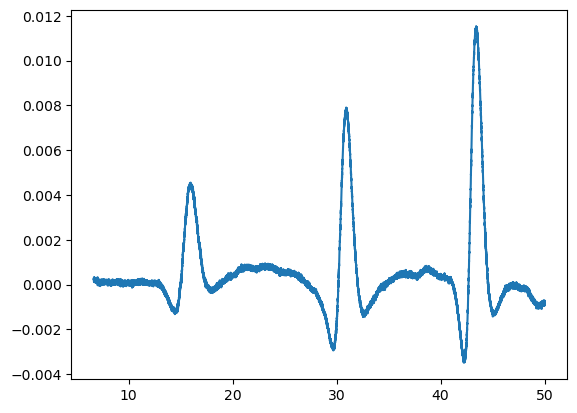

In [15]:
plt.plot(x, y)

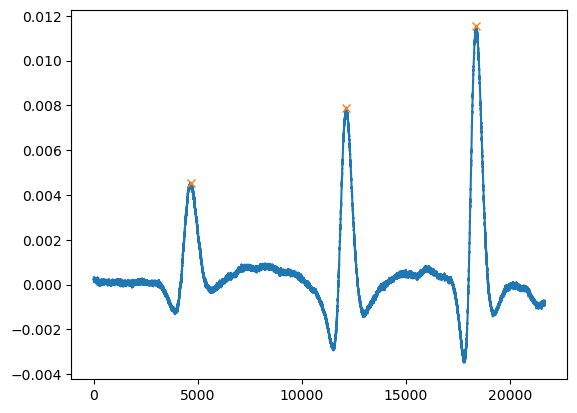

In [16]:
peaks, _ = find_peaks(y, height=0, distance=5000, width=333)
np.diff(peaks)
plt.plot(y)
plt.plot(peaks, y[peaks], "x")
plt.show()

xpik = x[peaks]
ypik = y[peaks]

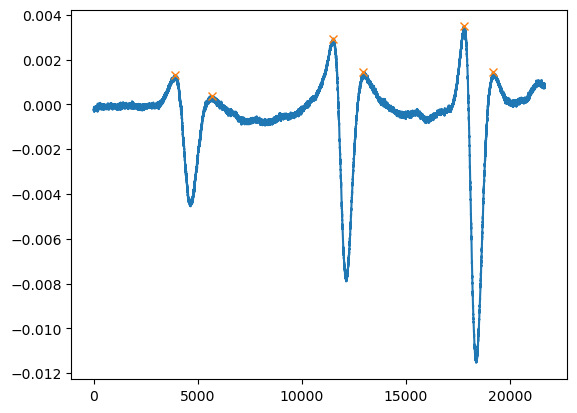

In [17]:
valleys, _ = find_peaks(-y, height=0, distance=1000, width=333)
np.diff(valleys)
plt.plot(-y)
plt.plot(valleys, -y[valleys], "x")
plt.show()

xval = x[valleys]
yval = y[valleys]

In [18]:
#vytvoreni pole objektu peaku
peak_objects = AssignPeaks(xpik, xval, ypik, yval)
numpeak = len(peak_objects)
#overeni delek poli minim a maxim
VerifyPeaksLength(xpik, xval, peak_objects)
#vypsat
SavePeakSpectra(peak_objects, x, y, InputFile, 2)

Peaks matched/consistent definition!
Total number of peaks identified in 2f-WMS signal is: 3
Peak1 centered at: 15.964(left minimum: 14.452; right minimum: 18.062)
Peak2 centered at: 30.916(left minimum: 29.68; right minimum: 32.536)
Peak3 centered at: 43.42(left minimum: 42.234; right minimum: 45.014)


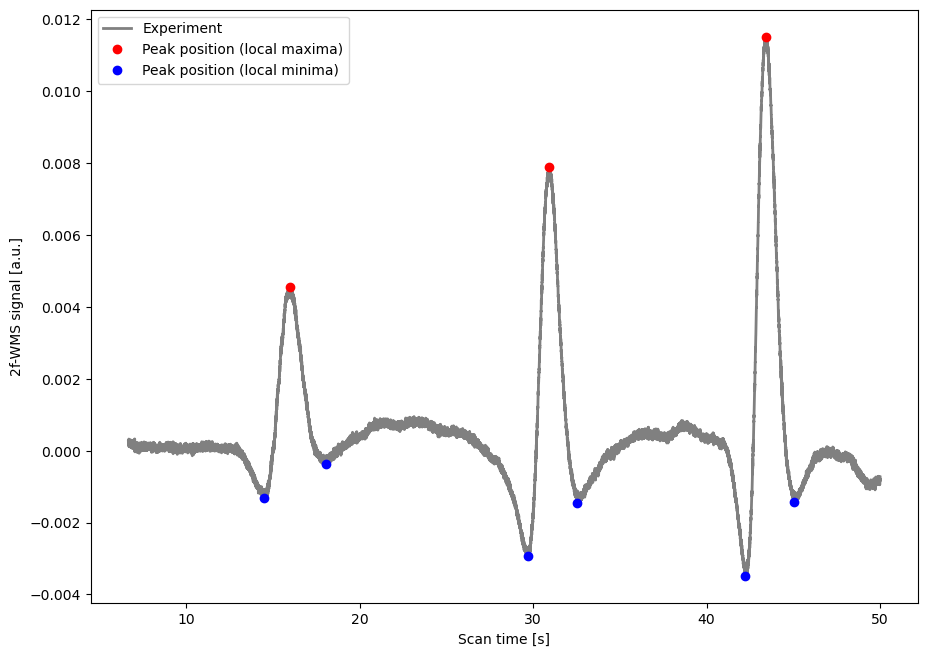

In [19]:
plt.figure(1)

line1, = plt.plot(x, y, 'grey', linewidth=2, label='Experiment')
point1, = plt.plot(xpik, ypik, 'ro', linewidth=2, label='Peak position (local maxima)')
point2, = plt.plot(xval, yval, 'bo', linewidth=2, label='Peak position (local minima)')
plt.legend(handler_map={line1: HandlerLine2D(numpoints=1)})
plt.xlabel(r"Scan time [s]")
plt.ylabel(r"2f-WMS signal [a.u.]")

plt.tight_layout()
a4 = plt.gcf()
a4.set_size_inches([10,7])
a4.savefig(Out1, format='pdf')
plt.show()

Out1.close()

In [20]:
def lorentzianA(x, a0, a1, a2):
    return a0/(np.pi*a2*(1+((x-a1)/a2)**2))

def D2lorentzianA(x, a0, a1, a2):
    return -2*a0*a2*(a2**2-3*(a1-x)**2)/(np.pi*(a2**2+(a1-x)**2)**3)

def gaussianA(x, a0, a1, a2):
    sigma = a2/np.sqrt(2*np.log(2))
    return a0/(sigma*np.sqrt(2*np.pi))*np.exp(-(x-a1)**2/(2*sigma**2))

def D2gaussianA(x, a0, a1, a2):
    sigma = np.sqrt(2*np.log(2))*a2
    poly2 = ((x-a1)**2-sigma**2)/sigma**4
    return poly2*a0/(sigma*np.sqrt(2*np.pi))*np.exp(-(x-a1)**2/(2*sigma**2))

In [21]:
result=[None]*numpeak
par=[None]*numpeak
resdata=[None]*numpeak
ofst=[None]*numpeak
minner=[None]*numpeak
res2ult=[None]*numpeak
fin2ual=[None]*numpeak
res2data=[None]*numpeak
par2am=[None]*numpeak
gabor2=[None]*numpeak
gabor4=[None]*numpeak
gabor6=[None]*numpeak
gabor8=[None]*numpeak

[[Fit Statistics]]
    # fitting method   = differential_evolution
    # function evals   = 920
    # data points      = 7606
    # variables        = 3
    chi-square         = 0.00258564
    reduced chi-square = 3.4008e-07
    Akaike info crit   = -113281.373
    Bayesian info crit = -113260.563
    R-squared          = 0.72647819
[[Variables]]
    a0: -0.03566581 +/- 5.3675e-04 (1.50%) (init = 0.00455023)
    a1:  16.0483040 +/- 0.00410241 (0.03%) (init = 8.662)
    a2:  1.76827912 +/- 0.00969738 (0.55%) (init = 3.042)
[[Correlations]] (unreported correlations are < 0.100)
    C(a0, a2) = -0.9106
    C(a1, a2) = +0.1757
    C(a0, a1) = -0.1600
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 278
    # data points      = 7606
    # variables        = 11
    chi-square         = 4.4383e-04
    reduced chi-square = 5.8438e-08
    Akaike info crit   = -126669.263
    Bayesian info crit = -126592.960
##  Warning: uncertainties could not be estimated:
    a1:  

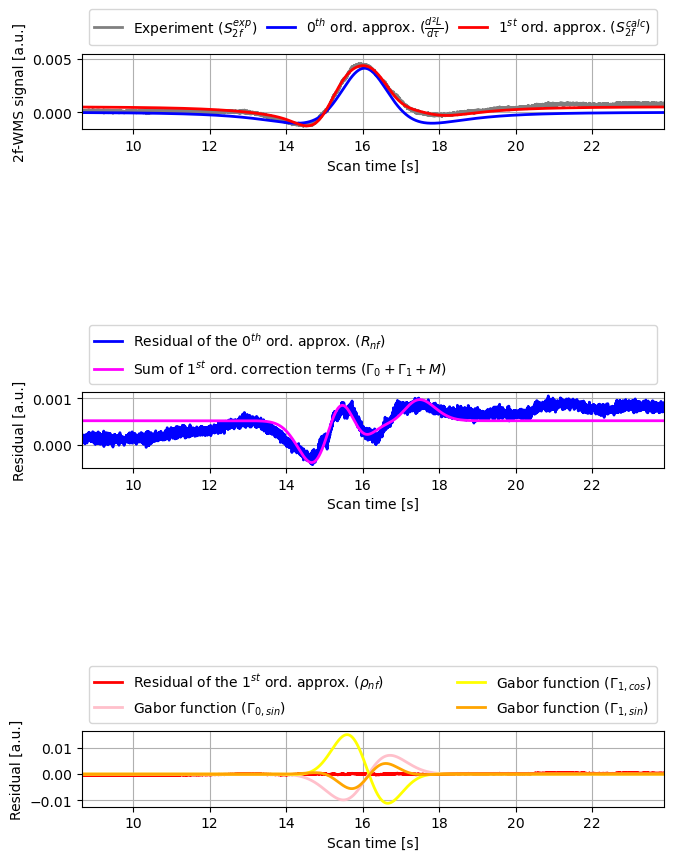

[[Fit Statistics]]
    # fitting method   = differential_evolution
    # function evals   = 1206
    # data points      = 6269
    # variables        = 3
    chi-square         = 0.00180507
    reduced chi-square = 2.8807e-07
    Akaike info crit   = -94408.4578
    Bayesian info crit = -94388.2276
    R-squared          = 0.93455752
[[Variables]]
    a0: -0.04042136 +/- 3.1791e-04 (0.79%) (init = 0.00790299)
    a1:  30.9998352 +/- 0.00183609 (0.01%) (init = 24.85)
    a2:  1.48924364 +/- 0.00425482 (0.29%) (init = 2.5072)
[[Correlations]] (unreported correlations are < 0.100)
    C(a0, a2) = -0.9083
    C(a1, a2) = +0.1866
    C(a0, a1) = -0.1695
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 437
    # data points      = 6269
    # variables        = 11
    chi-square         = 1.5658e-04
    reduced chi-square = 2.5021e-08
    Akaike info crit   = -109718.754
    Bayesian info crit = -109644.577
##  Warning: uncertainties could not be estimated:
    a1:

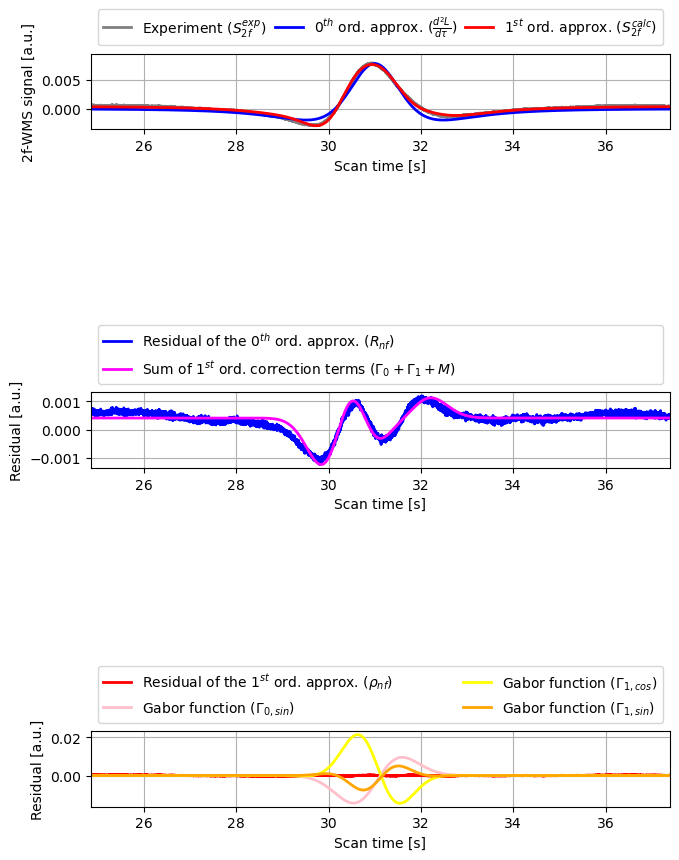

[[Fit Statistics]]
    # fitting method   = differential_evolution
    # function evals   = 1345
    # data points      = 6231
    # variables        = 3
    chi-square         = 0.00599644
    reduced chi-square = 9.6282e-07
    Akaike info crit   = -86317.5373
    Bayesian info crit = -86297.3254
    R-squared          = 0.88911140
[[Variables]]
    a0: -0.05355870 +/- 5.8214e-04 (1.09%) (init = 0.0115227)
    a1:  43.5045388 +/- 0.00237778 (0.01%) (init = 37.404)
    a2:  1.46479586 +/- 0.00583396 (0.40%) (init = 2.492)
[[Correlations]] (unreported correlations are < 0.100)
    C(a0, a2) = -0.9162
    C(a1, a2) = +0.2020
    C(a0, a1) = -0.1851
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 505
    # data points      = 6231
    # variables        = 11
    chi-square         = 0.00200977
    reduced chi-square = 3.2311e-07
    Akaike info crit   = -93112.9408
    Bayesian info crit = -93038.8306
##  Warning: uncertainties could not be estimated:
    a1: 

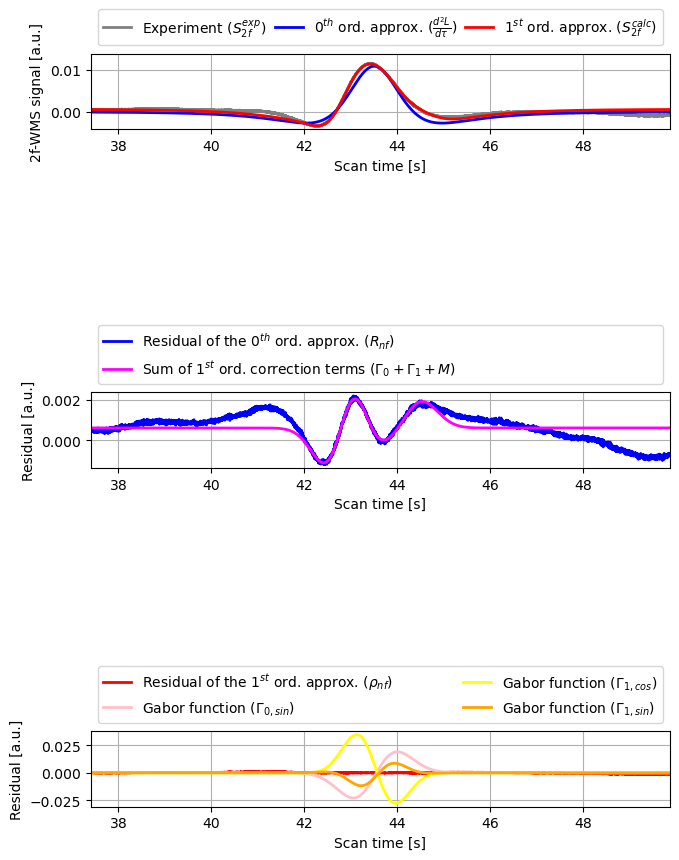

In [22]:
for i in range(1,numpeak+1):
    j=i-1
    
    InputFilePeaks = InputFile.replace(".txt", '_Peak') + str(i) + '.txt'
    Dataset = np.loadtxt(InputFilePeaks, skiprows= 0 + 1 + 2 + 3 + 4 , delimiter=',')
    x = Dataset[:, 0]
    y = Dataset[:, 1]

    Out3i = PdfPages('out_peakfit' + str(i) + '.pdf')
    
    params = lm.Parameters()
    params.add('a0', value=np.maximum(np.abs(np.amax(-y)),np.abs(np.amin(-y))), min=10*np.amin(-y), max=10*np.amax(-y))
    params.add('a1', value=np.amin(x)-(np.amax(x)-np.amin(x))/2, min=np.amin(x), max=np.amax(x))
    params.add('a2', value=(np.amax(x)-np.amin(x))/5, min=(np.amax(x)-np.amin(x))/10, max=(np.amax(x)-np.amin(x))/2)

    #model = lm.Model(D2gaussianA)
    model = lm.Model(D2lorentzianA)
     #result[j] = model.fit(y, params, x=x, method='leastsq')
    result[j] = model.fit(y, params, x=x, method='differential_evolution')
    
    lm.report_fit(result[j])

    par[j] = result[j].best_values
   
    resdata[j] = result[j].residual
    
    ofst[j] = np.mean(resdata[j])
    
    def residual(params, x, resdata):
        "Gabor polynomial"
        params['a0']= Parameter(name = 'a0', value = par[j]['a0'] , vary = False)
        params['a1']= Parameter(name = 'a1', value = par[j]['a1'] , vary = True)
        params['a2']= Parameter(name = 'a2', value = par[j]['a2'] , vary = False)

        off = params['off']
        params['off']= Parameter(name = 'off', value = ofst[j] , vary = False)
        k2 = params['k2']
        k4 = params['k4']
        k6 = params['k6']

        #k8 = params['k8']
        #fi8 = params['fi8']

        fi6 = params['fi6']
        fi4 = params['fi4']
        fi2 = params['fi2']
        
        a0 = params['a0']
        a1 = params['a1']
        a2 = params['a2']

        w = params['w']

        sigma = a2/np.sqrt(2*np.log(2))
        #gabor8 = np.cos(2*np.pi*(0/2)*(x-a1)/(2*a2)+fi8)*a0/((w*sigma)*np.sqrt(2*np.pi))*np.exp(-(x-a1)**2/(2*(w*sigma)**2))
        gabor6 = np.sin(2*np.pi*(3/2)*(x-a1)/(2*a2)+fi6)*a0/((w*sigma)*np.sqrt(2*np.pi))*np.exp(-(x-a1)**2/(2*(w*sigma)**2))
        gabor4 = np.cos(2*np.pi*(2/2)*(x-a1)/(2*a2)+fi4)*a0/((w*sigma)*np.sqrt(2*np.pi))*np.exp(-(x-a1)**2/(2*(w*sigma)**2))
        gabor2 = np.sin(2*np.pi*(1/2)*(x-a1)/(2*a2)+fi2)*a0/((w*sigma)*np.sqrt(2*np.pi))*np.exp(-(x-a1)**2/(2*(w*sigma)**2))
        
        #return off + k8*gabor8 + k6*gabor6 + k4*gabor4 + k2*gabor2 - resdata
        return off + k6*gabor6 + k4*gabor4 + k2*gabor2 - resdata
    
        # create a set of Parameters
    
    params.add('off', min=0, max=par[j]['a0'])
    params.add('k6', value=1.0, min=0.3, max=30.0, vary = True)
    params.add('k4', value=1.0, min=0.3, max=30.0, vary = True)
    params.add('k2', value=1.0, min=0.3, max=30.0, vary = True)
    #params.add('k8', value=1.0, min=-2.5, max=+2.5, vary = True)
    #params.add('fi8', value=0.0, min=-np.pi, max=np.pi, vary = False)
    params.add('fi6', value=0.0, min=-np.pi, max=np.pi, vary = True)
    params.add('fi4', value=0.0, min=-np.pi, max=np.pi, vary = True)
    params.add('fi2', value=0.0, min=-np.pi, max=np.pi, vary = True)
    params.add('w', value=1, min=1/3, max=4/3, vary = True)

       
    # do fit, here with leastsq model
    minner[j] = Minimizer(residual, params, fcn_args=(x, resdata[j]))
    res2ult[j] = minner[j].minimize(method = 'leastsq')
    # res2ult[j] = minner[j].minimize(method = 'differential_evolution')

    par2am[j] = res2ult[j].params
    #par2am[j].pretty_print()

    offj=par2am[j]['off'].value
    a0j=par2am[j]['a0'].value
    a1j=par2am[j]['a1'].value
    a2j=par2am[j]['a2'].value
    k6j=par2am[j]['k6'].value
    k4j=par2am[j]['k4'].value
    k2j=par2am[j]['k2'].value
    #k8j=par2am[j]['k8'].value
    #fi8j=par2am[j]['fi8'].value
    fi6j=par2am[j]['fi6'].value
    fi4j=par2am[j]['fi4'].value
    fi2j=par2am[j]['fi2'].value
    sigmaj = a2j/np.sqrt(2*np.log(2))
    wj=par2am[j]['w'].value

    #gabor8[j] = np.cos(0*np.pi*(x-a1j)/(2*a2j)+fi8j)*k8j*a0j/(wj*sigmaj*np.sqrt(2*np.pi))*np.exp(-(x-a1j)**2/(2*(wj*sigmaj)**2))
    gabor6[j] = np.sin(3*np.pi*(x-a1j)/(2*a2j)+fi6j)*k6j*a0j/(wj*sigmaj*np.sqrt(2*np.pi))*np.exp(-(x-a1j)**2/(2*(wj*sigmaj)**2))
    gabor4[j] = np.cos(2*np.pi*(x-a1j)/(2*a2j)+fi4j)*k4j*a0j/(wj*sigmaj*np.sqrt(2*np.pi))*np.exp(-(x-a1j)**2/(2*(wj*sigmaj)**2))
    gabor2[j] = np.sin(1*np.pi*(x-a1j)/(2*a2j)+fi2j)*k2j*a0j/(wj*sigmaj*np.sqrt(2*np.pi))*np.exp(-(x-a1j)**2/(2*(wj*sigmaj)**2))

    res2data[j] = res2ult[j].residual
    
    # calculate final result
    fin2ual[j] = resdata[j] + res2data[j]
    
    # write error report
    report_fit(res2ult[j])
    
    fig2 = plt.figure(2)
    
    ax1=plt.subplot(311)
    line2, = plt.plot(x, y, 'grey', linewidth=2, label= r'Experiment ($S_{2f}^{exp}$)')
    line3, = plt.plot(x, result[j].best_fit, 'blue', linewidth=2, label= r'$0^{th}$ ord. approx. ($\frac{d^{2}L}{d\tau}$)')
    line3f, = plt.plot(x, result[j].best_fit-fin2ual[j], 'red', linewidth=2, label= r'$1^{st}$ ord. approx. ($S_{2f}^{calc}$)')
    plt.legend(handler_map={line1: HandlerLine2D(numpoints=1)})
    plt.legend(bbox_to_anchor=(0,1.02,1,0.2), loc="lower left", mode="expand", ncol=3)
    plt.xlabel(r"Scan time [s]")
    plt.ylabel(r"2f-WMS signal [a.u.]")
    plt.axis([1.0*np.amin(x), 1.0*np.amax(x), 1.2*np.amin(y), 1.2*np.amax(y),])
    plt.grid(True)

    ax2=plt.subplot(312, sharex=ax1)
    line4, = plt.plot(x, -result[j].residual, 'blue',linewidth=2, label=r'Residual of the $0^{th}$ ord. approx. ($R_{nf}$)')
    line5, = plt.plot(x, -fin2ual[j], 'magenta', linewidth=2, label=r'Sum of $1^{st}$ ord. correction terms ($\Gamma_0 + \Gamma_1 + M$)')
    plt.legend(handler_map={line4: HandlerLine2D(numpoints=1)})
    plt.legend(bbox_to_anchor=(0,1.02,1,0.2), loc="lower left", mode="expand", ncol=1)
    plt.xlabel(r"Scan time [s]")
    plt.ylabel(r"Residual [a.u.]")
    #plt.axis([1.0*np.amin(x), 1.0*np.amax(x), -1.5*np.amax(result[j].residual), -2.5*np.amin(result[j].residual),])
    plt.grid(True)
    
    ax3=plt.subplot(313, sharex=ax1)
    line6, = plt.plot(x, res2ult[j].residual, 'red',linewidth=2, label=r'Residual of the $1^{st}$ ord. approx. ($\rho_{nf}$)')
    line7, = plt.plot(x, -gabor2[j], 'pink',linewidth=2, label= r'Gabor function ($\Gamma_{0,sin}$)')
    line8, = plt.plot(x, -gabor4[j], 'yellow',linewidth=2, label= r'Gabor function ($\Gamma_{1,cos}$)')
    line9, = plt.plot(x, -gabor6[j], 'orange',linewidth=2, label=r'Gabor function ($\Gamma_{1,sin}$)')
    #line10, = plt.plot(x, gabor8[j], 'cyan',linewidth=2, label='Gabor function (n=8)')
    #line11, = plt.plot(x, -gabor2[j]-gabor4[j]-gabor6[j]-gabor8[j], 'm:',linewidth=4)
    plt.legend(handler_map={line6: HandlerLine2D(numpoints=1)})
    plt.legend(bbox_to_anchor=(0,1.02,1,0.2), loc="lower left", mode="expand", ncol=2)
    plt.xlabel(r"Scan time [s]")
    plt.ylabel(r"Residual [a.u.]")
    #plt.axis([1.0*np.amin(x), 1.0*np.amax(x), 2.0*offj-1.5*np.amax(result[j].residual), 2.0*offj-2.5*np.amin(result[j].residual),])
    plt.grid(True)
    
    plt.tight_layout()
    a4 = plt.gcf()
    a4.set_size_inches([7,10])
    a4.savefig(Out2, format='pdf')
    a4.savefig(Out3i, format='pdf')
    plt.show()

    Out3i.close()
    
Out2.close()